https://www.kaggle.com/code/pythonafroz/20-models-steel-plant-load-prediction-96-auc

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline

from lightgbm import LGBMClassifier
from sklearn.linear_model import RidgeClassifierCV
from xgboost import XGBClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as Xgb
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
import lightgbm as lgb
from sklearn.svm import NuSVC
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.linear_model import RidgeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import PassiveAggressiveClassifier


from sklearn.metrics import accuracy_score, classification_report,f1_score,confusion_matrix,precision_score,recall_score,balanced_accuracy_score
from sklearn.metrics import confusion_matrix,  roc_auc_score

import warnings
warnings.filterwarnings("ignore")

C:\IT\workspace_python\.venv\lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:18: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


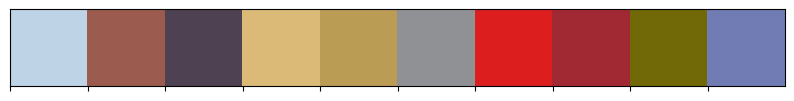

In [2]:
# Color Palettes
colors = ["#bfd3e6", "#9b5b4f", "#4e4151", "#dbba78", "#bb9c55", "#909195","#dc1e1e","#a02933","#716807","#717cb4"]
sns.palplot(sns.color_palette(colors))

In [3]:
#Default theme
sns.set_theme(palette='tab10',
              font='Comic Sans MS',
              font_scale=1.5,
              rc=None)

import matplotlib
matplotlib.rcParams.update({'font.size': 15})
plt.style.use('dark_background')
plt.rcParams["axes.grid"] = False

In [4]:
df = pd.read_csv("Steel_industry_data.csv")
df.head().style.background_gradient(cmap='copper')

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.170000,2.950000,0.000000,0.000000,73.210000,100.000000,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.000000,4.460000,0.000000,0.000000,66.770000,100.000000,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.240000,3.280000,0.000000,0.000000,70.280000,100.000000,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.310000,3.560000,0.000000,0.000000,68.090000,100.000000,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.820000,4.500000,0.000000,0.000000,64.720000,100.000000,4500,Weekday,Monday,Light_Load


In [5]:
df.describe().T.round(2).sort_values(by='std' , ascending = False)\
                     .style.background_gradient(cmap='GnBu')\
                     .bar(subset=["max"], color='#BB0000')\
                     .bar(subset=["min",], color='green')\
                     .bar(subset=["mean",], color='Orange')\
                     .bar(subset=['std'], color='#716807')\
                     .bar(subset=['50%'], color='#717cb4')

,count,mean,std,min,25%,50%,75%,max
NSM,35040.000000,42750.000000,24940.530000,0.000000,21375.000000,42750.000000,64125.000000,85500.000000
Usage_kWh,35040.000000,27.390000,33.440000,0.000000,3.200000,4.570000,51.240000,157.180000
Leading_Current_Power_Factor,35040.000000,84.370000,30.460000,0.000000,99.700000,100.000000,100.000000,100.000000
Lagging_Current_Power_Factor,35040.000000,80.580000,18.920000,0.000000,63.320000,87.960000,99.020000,100.000000
Lagging_Current_Reactive.Power_kVarh,35040.000000,13.040000,16.310000,0.000000,2.300000,5.000000,22.640000,96.910000
Leading_Current_Reactive_Power_kVarh,35040.000000,3.870000,7.420000,0.000000,0.000000,0.000000,2.090000,27.760000
CO2(tCO2),35040.000000,0.010000,0.020000,0.000000,0.000000,0.000000,0.020000,0.070000


In [6]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True )

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  35040 non-null  datetime64[ns]
 1   Usage_kWh                             35040 non-null  float64       
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64       
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64       
 4   CO2(tCO2)                             35040 non-null  float64       
 5   Lagging_Current_Power_Factor          35040 non-null  float64       
 6   Leading_Current_Power_Factor          35040 non-null  float64       
 7   NSM                                   35040 non-null  int64         
 8   WeekStatus                            35040 non-null  object        
 9   Day_of_week                           35040 non-null  object        
 10

In [8]:
df.nunique().sort_values(ascending=False)

date                                    35040
Lagging_Current_Power_Factor             5079
Leading_Current_Power_Factor             3366
Usage_kWh                                3343
Lagging_Current_Reactive.Power_kVarh     1954
Leading_Current_Reactive_Power_kVarh      768
NSM                                        96
CO2(tCO2)                                   8
Day_of_week                                 7
Load_Type                                   3
WeekStatus                                  2
dtype: int64

In [9]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"[{col}] ({df[col].nunique()} unique values):")
    print(df[col].unique())
    print("-" * 30)

[WeekStatus] (2 unique values):
['Weekday' 'Weekend']
------------------------------
[Day_of_week] (7 unique values):
['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']
------------------------------
[Load_Type] (3 unique values):
['Light_Load' 'Medium_Load' 'Maximum_Load']
------------------------------


In [10]:
df['NSM'].unique()

array([  900,  1800,  2700,  3600,  4500,  5400,  6300,  7200,  8100,
        9000,  9900, 10800, 11700, 12600, 13500, 14400, 15300, 16200,
       17100, 18000, 18900, 19800, 20700, 21600, 22500, 23400, 24300,
       25200, 26100, 27000, 27900, 28800, 29700, 30600, 31500, 32400,
       33300, 34200, 35100, 36000, 36900, 37800, 38700, 39600, 40500,
       41400, 42300, 43200, 44100, 45000, 45900, 46800, 47700, 48600,
       49500, 50400, 51300, 52200, 53100, 54000, 54900, 55800, 56700,
       57600, 58500, 59400, 60300, 61200, 62100, 63000, 63900, 64800,
       65700, 66600, 67500, 68400, 69300, 70200, 71100, 72000, 72900,
       73800, 74700, 75600, 76500, 77400, 78300, 79200, 80100, 81000,
       81900, 82800, 83700, 84600, 85500,     0])

In [11]:
 df['CO2(tCO2)'].unique()

array([0.  , 0.02, 0.03, 0.05, 0.06, 0.04, 0.01, 0.07])

In [12]:
class VizHelper:
    def __init__(self, df):
        self.df = df
        self.mappings = {}

    def easy_encode(self, columns):
        from sklearn.preprocessing import LabelEncoder
        for col in columns:
            le = LabelEncoder()
            self.df[col] = le.fit_transform(self.df[col])
            # 나중에 시각화에서 '글자'로 복구하기 위해 저장
            self.mappings[col] = dict(zip(le.transform(le.classes_), le.classes_))

In [13]:
# WeekStatus, Day_of_week, Load_Type

In [14]:
df_incoded = df.copy()

In [15]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

class SteelProcessManager:
    def __init__(self, df):
        self.df = df
        self.encoders = {}

    def preprocess(self, date_col='date', cat_cols=['WeekStatus', 'Day_of_week', 'Load_Type']):
        # 1. 날짜 데이터 인덱스 처리
        self.df[date_col] = pd.to_datetime(self.df[date_col], dayfirst=True)
        self.df.set_index(date_col, inplace=True)
        self.df.sort_index(inplace=True) # 시계열 분석을 위해 정렬 필수
        
        # 2. 카테고리 피처 라벨 인코딩 및 역변환용 객체 저장
        for col in cat_cols:
            if col in self.df.columns:
                le = LabelEncoder()
                self.df[col] = le.fit_transform(self.df[col])
                self.encoders[col] = le
        
        print(f"전처리 완료: 인덱스 기간({self.df.index.min()} ~ {self.df.index.max()})")
        return self.df

    def get_original_label(self, col_name, encoded_value):
        """숫자를 원래 문자열로 역변환"""
        if col_name in self.encoders:
            # 단일 값 처리를 위해 리스트화 후 변환
            return self.encoders[col_name].inverse_transform([encoded_value])[0]
        return encoded_value

# --- 실행 코드 ---
labelmanager = SteelProcessManager(df_incoded)
df_incoding = labelmanager.preprocess()

# 특정 날짜 데이터만 칼처럼 뽑아내기 (인덱스 처리의 강점)
# jan_data = df_final.loc['2018-01-01':'2018-01-07']

# 'Load_Type' 컬럼의 숫자 0이 원래 뭐였는지 확인
# original_val = manager.encoders['Load_Type'].inverse_transform([0])[0]
# print(original_val)  # 결과: 'Light_Load' (예시)



전처리 완료: 인덱스 기간(2018-01-01 00:00:00 ~ 2018-12-31 23:45:00)


In [16]:
df_incoded.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35040 entries, 2018-01-01 00:00:00 to 2018-12-31 23:45:00
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Usage_kWh                             35040 non-null  float64
 1   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 2   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   CO2(tCO2)                             35040 non-null  float64
 4   Lagging_Current_Power_Factor          35040 non-null  float64
 5   Leading_Current_Power_Factor          35040 non-null  float64
 6   NSM                                   35040 non-null  int64  
 7   WeekStatus                            35040 non-null  int64  
 8   Day_of_week                           35040 non-null  int64  
 9   Load_Type                             35040 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 2.9 MB


In [17]:
corr = df_incoded.corr()
df_incoded.corr().style.background_gradient(cmap='copper')

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
Usage_kWh,1.000000,0.896150,-0.324922,0.988180,0.385960,0.353566,0.234610,-0.295475,0.039865,0.444092
Lagging_Current_Reactive.Power_kVarh,0.896150,1.000000,-0.405142,0.886948,0.144534,0.407716,0.082662,-0.319870,0.043780,0.249674
Leading_Current_Reactive_Power_kVarh,-0.324922,-0.405142,1.000000,-0.332777,0.526770,-0.944039,0.371605,0.260431,-0.019785,0.223557
CO2(tCO2),0.988180,0.886948,-0.332777,1.000000,0.379605,0.360019,0.231726,-0.290467,0.036236,0.437742
Lagging_Current_Power_Factor,0.385960,0.144534,0.526770,0.379605,1.000000,-0.519967,0.565270,0.054082,0.001597,0.559395
Leading_Current_Power_Factor,0.353566,0.407716,-0.944039,0.360019,-0.519967,1.000000,-0.360563,-0.314675,0.021105,-0.131382
NSM,0.234610,0.082662,0.371605,0.231726,0.565270,-0.360563,1.000000,0.000000,-0.000000,0.593049
WeekStatus,-0.295475,-0.319870,0.260431,-0.290467,0.054082,-0.314675,0.000000,1.000000,-0.156082,-0.203308
Day_of_week,0.039865,0.043780,-0.019785,0.036236,0.001597,0.021105,-0.000000,-0.156082,1.000000,0.012682
Load_Type,0.444092,0.249674,0.223557,0.437742,0.559395,-0.131382,0.593049,-0.203308,0.012682,1.000000


In [18]:
df_incoded.describe().T.round(2).sort_values(by='std' , ascending = False)\
                     .style.background_gradient(cmap='GnBu')\
                     .bar(subset=["max"], color='#BB0000')\
                     .bar(subset=["min",], color='green')\
                     .bar(subset=["mean",], color='Orange')\
                     .bar(subset=['std'], color='#716807')\
                     .bar(subset=['50%'], color='#717cb4')

,count,mean,std,min,25%,50%,75%,max
NSM,35040.000000,42750.000000,24940.530000,0.000000,21375.000000,42750.000000,64125.000000,85500.000000
Usage_kWh,35040.000000,27.390000,33.440000,0.000000,3.200000,4.570000,51.240000,157.180000
Leading_Current_Power_Factor,35040.000000,84.370000,30.460000,0.000000,99.700000,100.000000,100.000000,100.000000
Lagging_Current_Power_Factor,35040.000000,80.580000,18.920000,0.000000,63.320000,87.960000,99.020000,100.000000
Lagging_Current_Reactive.Power_kVarh,35040.000000,13.040000,16.310000,0.000000,2.300000,5.000000,22.640000,96.910000
Leading_Current_Reactive_Power_kVarh,35040.000000,3.870000,7.420000,0.000000,0.000000,0.000000,2.090000,27.760000
Day_of_week,35040.000000,2.990000,2.000000,0.000000,1.000000,3.000000,5.000000,6.000000
Load_Type,35040.000000,0.760000,0.860000,0.000000,0.000000,0.000000,2.000000,2.000000
WeekStatus,35040.000000,0.280000,0.450000,0.000000,0.000000,0.000000,1.000000,1.000000
CO2(tCO2),35040.000000,0.010000,0.020000,0.000000,0.000000,0.000000,0.020000,0.070000


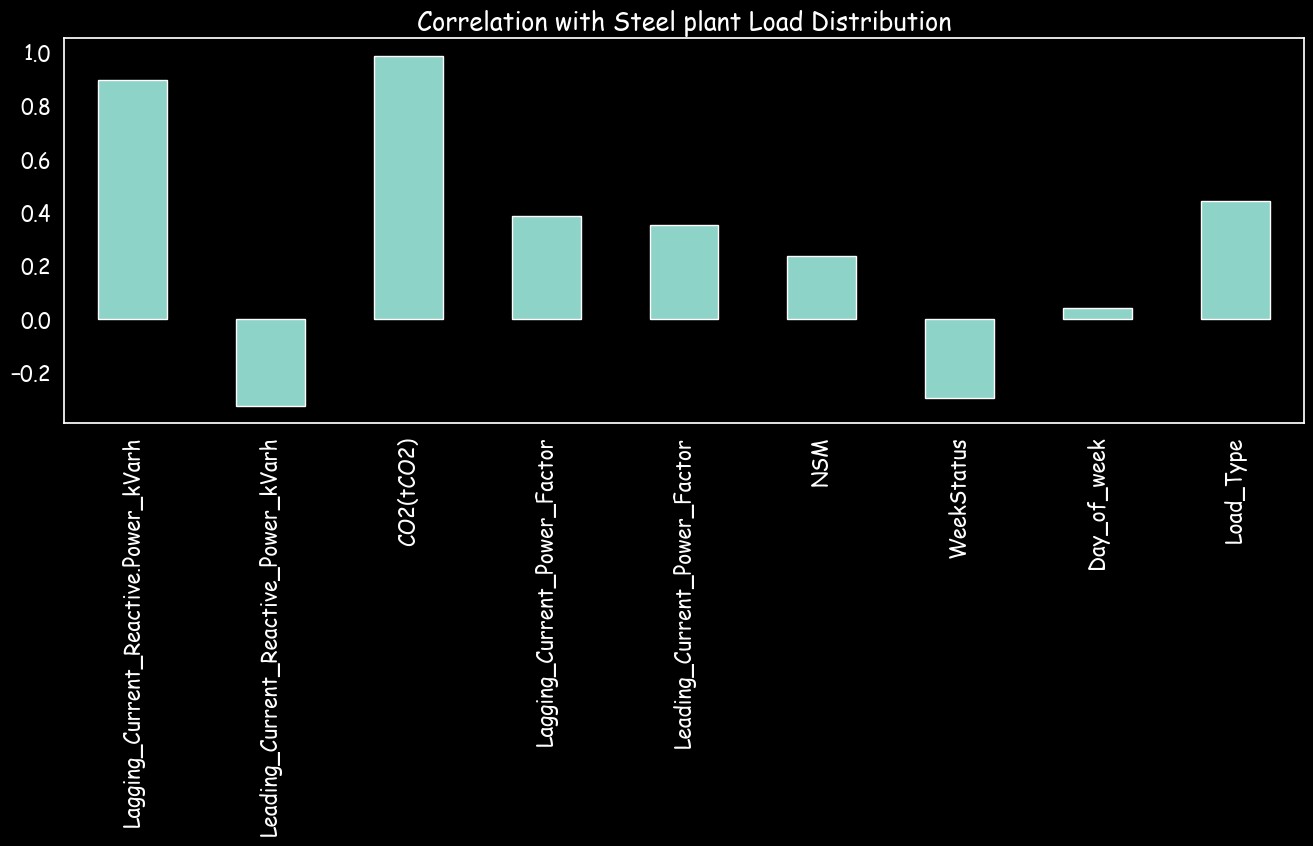

In [19]:
df1 = df_incoded.copy()
#Correlation with Response Variable class
X = df1.drop(['Usage_kWh'],axis=1)
y = df1['Usage_kWh']

X.corrwith(y).plot.bar(
        figsize = (16, 5), title = "Correlation with Steel plant Load Distribution", fontsize = 15,
        grid = False)
plt.show()

In [20]:
class color:
    BOLD = '\033[1m'
    END = '\033[0m'
print(f"\033[94m\033[1m")
print(color.BOLD + 'Missing values - Percentage: \n' + color.END)
print(f"\033[91m\033[1m")
print(round(df.isnull().mean() * 100, 2))


Missing values - Percentage: 


date                                    0.0
Usage_kWh                               0.0
Lagging_Current_Reactive.Power_kVarh    0.0
Leading_Current_Reactive_Power_kVarh    0.0
CO2(tCO2)                               0.0
Lagging_Current_Power_Factor            0.0
Leading_Current_Power_Factor            0.0
NSM                                     0.0
WeekStatus                              0.0
Day_of_week                             0.0
Load_Type                               0.0
dtype: float64


In [21]:
cat = df.select_dtypes(include='object').columns.tolist()

for col in df[cat]:
    print(f"\033[94m\033[1m")
    print(col,"\n")
    print(f"\033[91m\033[1m")
    print(df[col].value_counts())
    print(f"\033[92m\033[1m")
    print("======="*5)


WeekStatus 


WeekStatus
Weekday    25056
Weekend     9984
Name: count, dtype: int64


Day_of_week 


Day_of_week
Monday       5088
Tuesday      4992
Wednesday    4992
Thursday     4992
Friday       4992
Saturday     4992
Sunday       4992
Name: count, dtype: int64


Load_Type 


Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64



In [22]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import FunctionTransformer
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # imblearn용 파이프라인 필수

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet       # 선형모델
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBRegressor


# 로그 변환 함수 정의 (특정 컬럼만 골라서 변환하도록 설정)
def log_transform_cols(X):
    X_cp = X.copy()
    col_list = []
    # 컬럼 존재 여부 체크 로직을 넣으면 더 견고해짐
    target_cols = [c for c in col_list if c in X_cp.columns]
    X_cp[target_cols] = np.log1p(X_cp[target_cols])
    return X_cp


def get_pipeline(scaler, model):
    return Pipeline([
    # return Pipeline([
        ('log', FunctionTransformer(log_transform_cols)),
        ('scaler', scaler if scaler else 'passthrough'),
        # k_neighbors를 2로 낮춰 아주 적은 데이터(3개)도 증식 가능하게 함
        # ('smote', SMOTE(random_state=4567, sampling_strategy='auto', k_neighbors=2)),
        ('model', model)
    ])

def train_and_evaluate(X_train_full, X_test, y_train_full, y_test):
    # 모델 및 스케일러 리스트
    scaler_list = [None, StandardScaler()] #, MinMaxScaler(), RobustScaler()]
   
    model_list = [
        LinearRegression(),
        # DecisionTreeRegressor(random_state=42),
        # RandomForestRegressor(random_state=42),
        XGBRegressor(random_state=42), 
        # LGBMRegressor(random_state=42, verbosity=-1),
        Ridge(random_state=42),
        Lasso(random_state=42),
        ElasticNet(random_state=42)
    ]

    # 베스트 모델 기록을 위한 변수 초기화
    best_rmse = float('inf')
    best_pipe = None
    best_model_name = ""
    best_scaler_name = ""
    
    for scaler in scaler_list:
        for model in model_list:
            model_name = model.__class__.__name__
            scaler_name = scaler.__class__.__name__ if scaler else "None"
            print(f"\n🚀 Testing: {scaler_name} + {model_name}")
            
            pipe = get_pipeline(scaler, model)
            
            pipe.fit(X_train_full, y_train_full)
            
            pred = pipe.predict(X_test)
            mse = mean_squared_error(y_test, pred)
            rmse = np.sqrt(mse)
            print(f"MSE : {mse:.4f}")
            print(f"RMSE: {rmse:.4f}")

            if rmse < best_rmse:
                best_rmse = rmse
                best_pipe = pipe
                best_model_name = model_name
                best_scaler_name = scaler_name

            
            # ==========================================
    # 베스트 모델 선정 결과 보고 및 Importance 확인
    # ==========================================
    print("\n" + "="*50)
    print(f"🏆 BEST MODEL: {best_scaler_name} + {best_model_name}")
    print(f"📊 BEST RMSE : {best_rmse:.4f}")
    print("="*50)

    # 파이프라인에서 실제 모델 객체 추출
    final_model = best_pipe.named_steps['model']

    # Importance 확인 (트리 기반 모델인 경우)
    if hasattr(final_model, 'feature_importances_'):
        print(f"\n✨ {best_model_name} Feature Importances:")
        
        importances = final_model.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        # 시각화
        plt.figure(figsize=(12, 6))
        plt.title(f"Feature Importances: {best_model_name}")
        sns.barplot(x=importances[indices][:10], y=X_train_full.columns[indices][:10], palette='magma')
        plt.xlabel("Relative Importance")
        plt.tight_layout()
        plt.show()
        
        # 상위 5개 수치 출력
        for i in range(5):
            print(f"{i+1}. {X_train_full.columns[indices[i]]}: {importances[indices[i]]:.4f}")
    else:
        print(f"\nℹ️ {best_model_name} 모델은 Feature Importance를 직접 제공하지 않습니다.")

In [23]:
df_incoded.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35040 entries, 2018-01-01 00:00:00 to 2018-12-31 23:45:00
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Usage_kWh                             35040 non-null  float64
 1   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 2   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   CO2(tCO2)                             35040 non-null  float64
 4   Lagging_Current_Power_Factor          35040 non-null  float64
 5   Leading_Current_Power_Factor          35040 non-null  float64
 6   NSM                                   35040 non-null  int64  
 7   WeekStatus                            35040 non-null  int64  
 8   Day_of_week                           35040 non-null  int64  
 9   Load_Type                             35040 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 2.9 MB


In [24]:
from sklearn.model_selection import train_test_split

X = df_incoded.drop('Usage_kWh', axis=1)
y = df_incoded['Usage_kWh']

X80, X20, y80, y20 = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LinearRegression       # 선형모델
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBRegressor

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import mean_squared_error


#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV




🚀 Testing: None + LinearRegression
MSE : 18.7666
RMSE: 4.3320

🚀 Testing: None + XGBRegressor
MSE : 1.3210
RMSE: 1.1494

🚀 Testing: None + Ridge
MSE : 45.5086
RMSE: 6.7460

🚀 Testing: None + Lasso
MSE : 96.5520
RMSE: 9.8261

🚀 Testing: None + ElasticNet
MSE : 96.3648
RMSE: 9.8166

🚀 Testing: StandardScaler + LinearRegression
MSE : 18.7666
RMSE: 4.3320

🚀 Testing: StandardScaler + XGBRegressor
MSE : 1.3210
RMSE: 1.1494

🚀 Testing: StandardScaler + Ridge
MSE : 18.7687
RMSE: 4.3323

🚀 Testing: StandardScaler + Lasso
MSE : 20.7944
RMSE: 4.5601

🚀 Testing: StandardScaler + ElasticNet
MSE : 78.5432
RMSE: 8.8625

🏆 BEST MODEL: None + XGBRegressor
📊 BEST RMSE : 1.1494

✨ XGBRegressor Feature Importances:


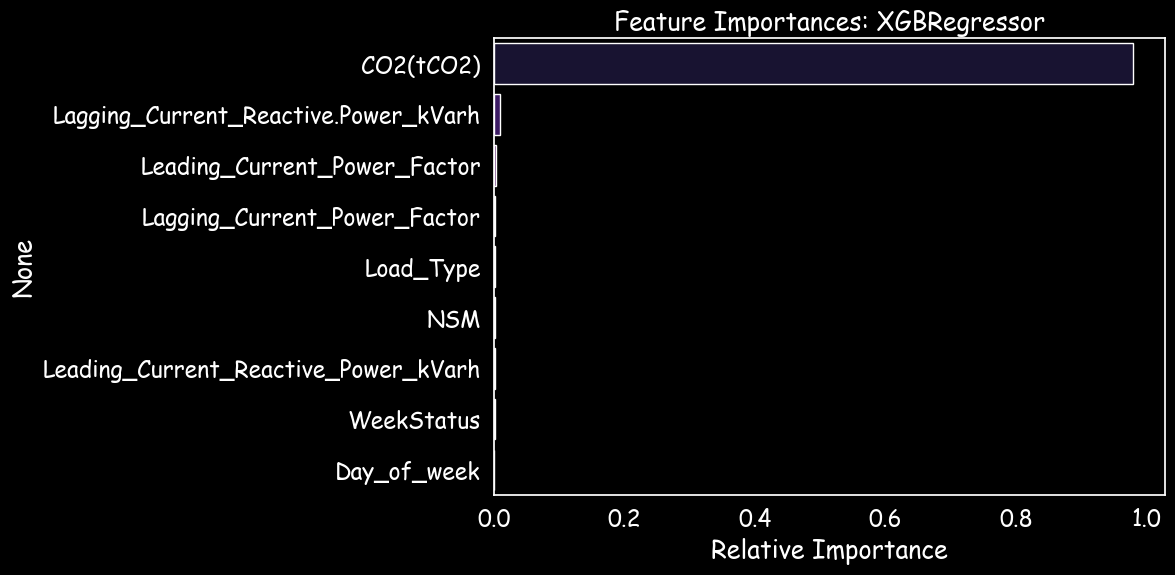

1. CO2(tCO2): 0.9799
2. Lagging_Current_Reactive.Power_kVarh: 0.0097
3. Leading_Current_Power_Factor: 0.0032
4. Lagging_Current_Power_Factor: 0.0023
5. Load_Type: 0.0015


In [26]:
train_and_evaluate(X80, X20, y80, y20)

In [27]:
X.columns

Index(['Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')

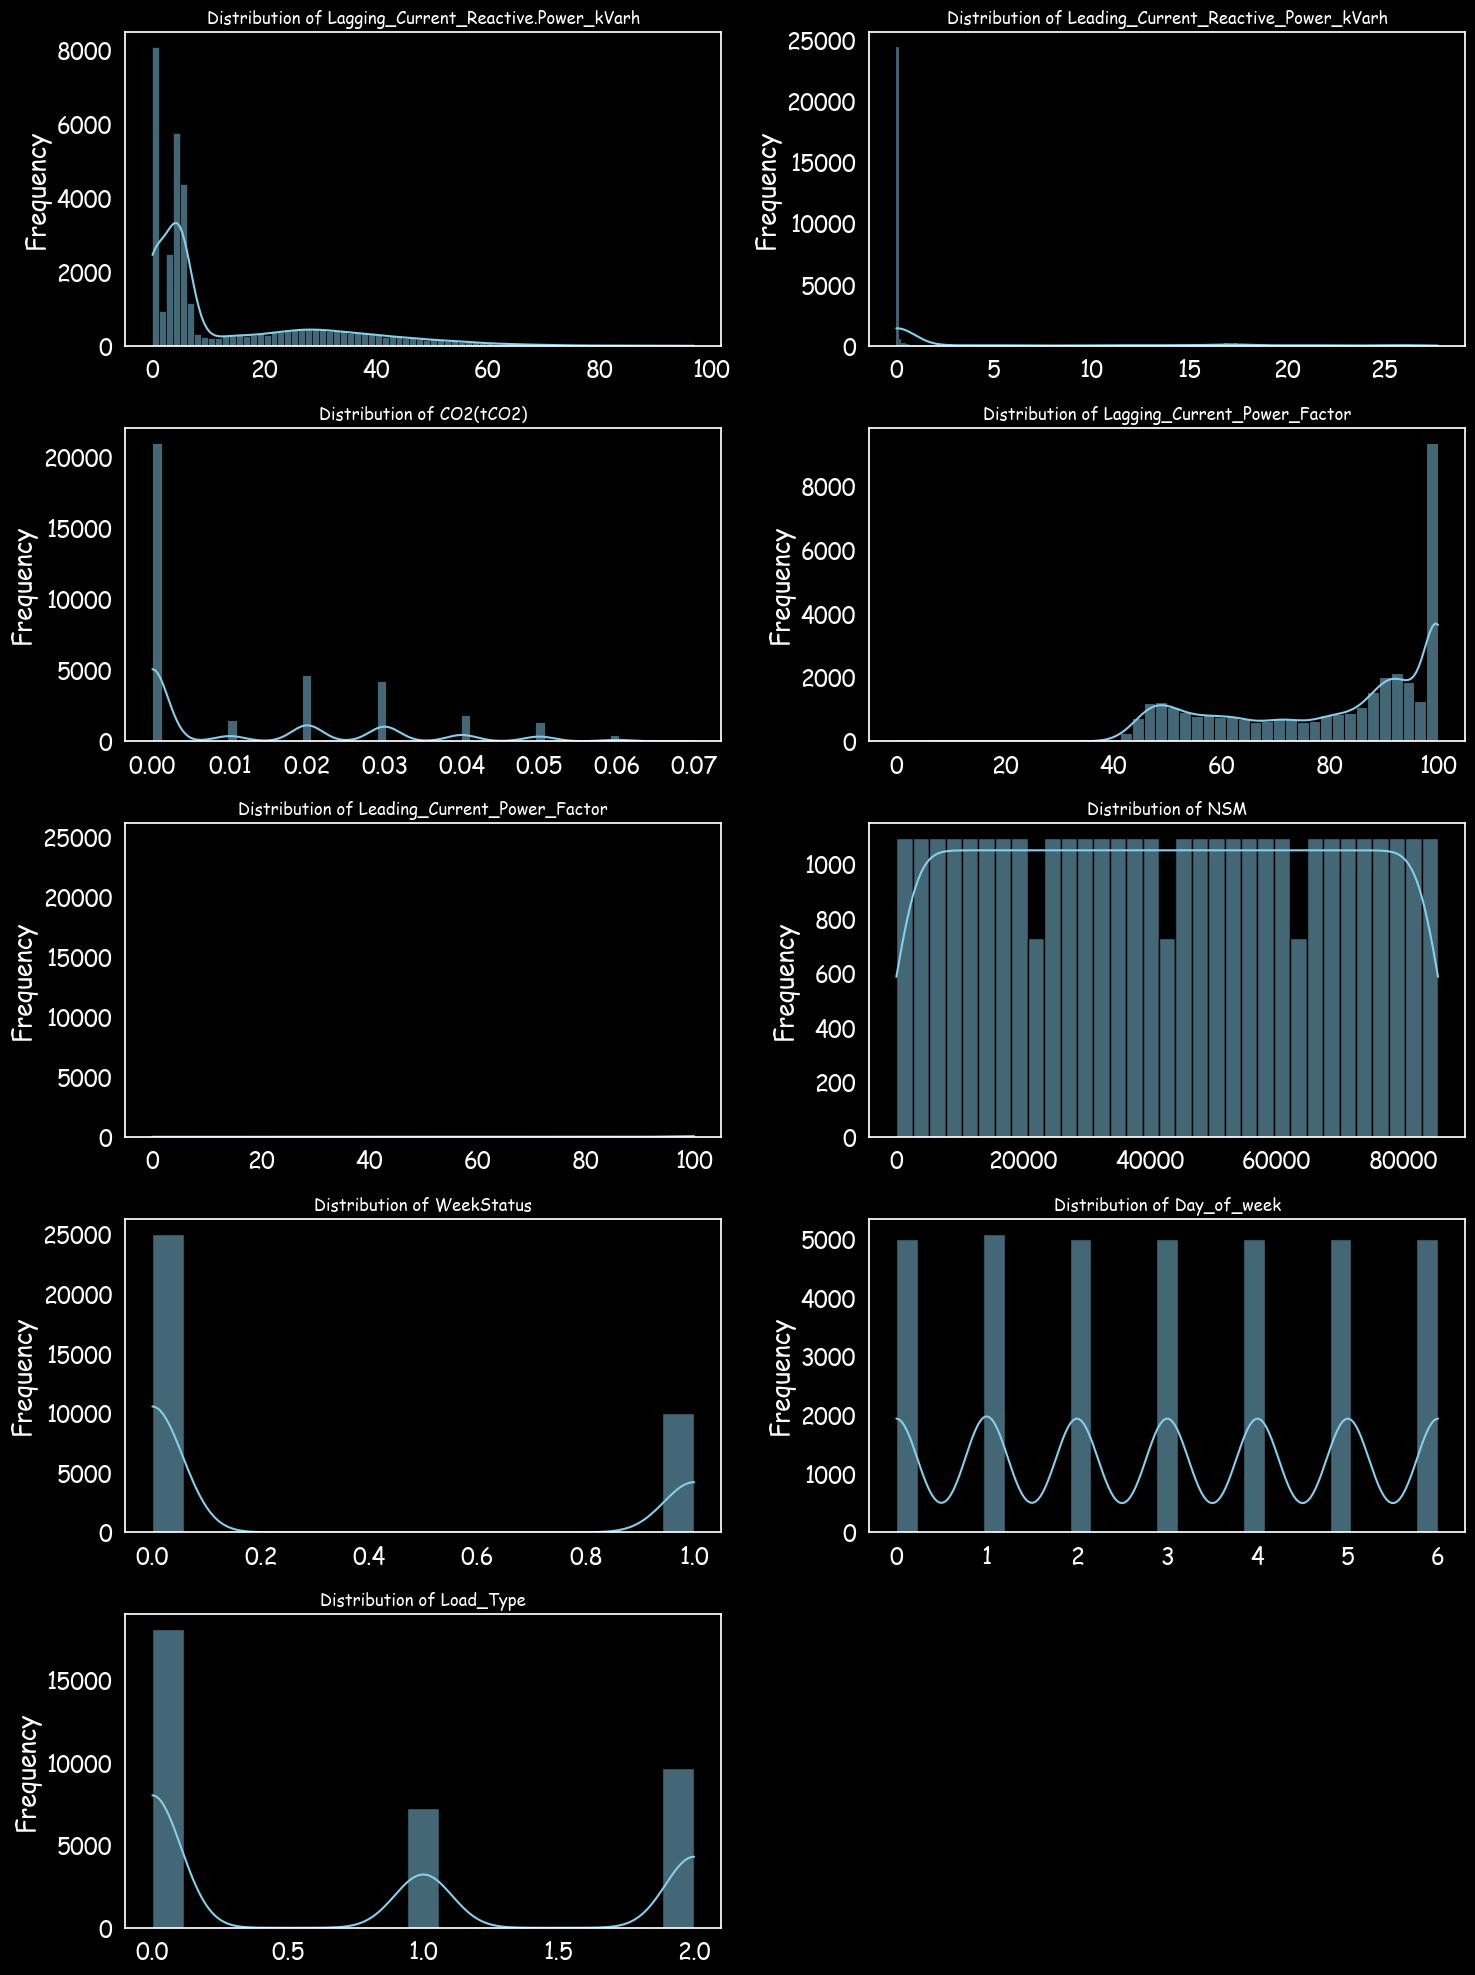

In [29]:
# 시각화할 수치형 피처 7개 선택
cols = ['Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type']

# 5행 2열의 서브플롯 생성
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
axes = axes.flatten() # 2차원 배열을 1차원으로 펼쳐서 반복문 돌리기 쉽게 만듦

for i, col in enumerate(cols):
    sns.histplot(X[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# 8번째 빈 칸(마지막 서브플롯)은 삭제
if len(cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [31]:
y.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 35040 entries, 2018-01-01 00:00:00 to 2018-12-31 23:45:00
Series name: Usage_kWh
Non-Null Count  Dtype  
--------------  -----  
35040 non-null  float64
dtypes: float64(1)
memory usage: 547.5 KB


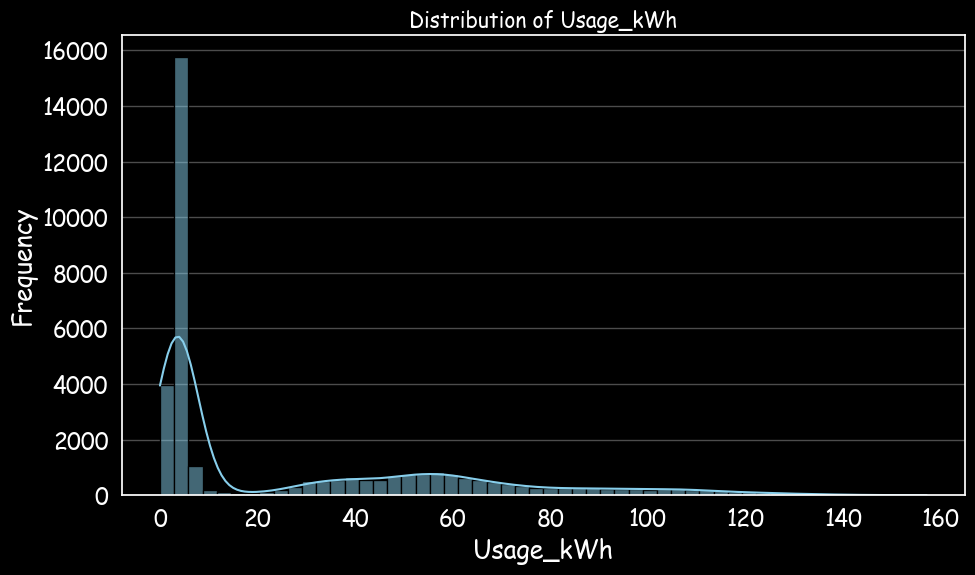

In [33]:
# 시각화할 피처 선택
col = 'Usage_kWh'

# 단일 그래프 생성
plt.figure(figsize=(10, 6))

# y가 Series라면 y, DataFrame이라면 y[col]로 입력하세요.
# 만약 y가 전력 사용량 타겟값(Series)인 경우:
sns.histplot(y, kde=True, color='skyblue', edgecolor='black')

plt.title(f'Distribution of {col}', fontsize=15)
plt.xlabel(col)
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

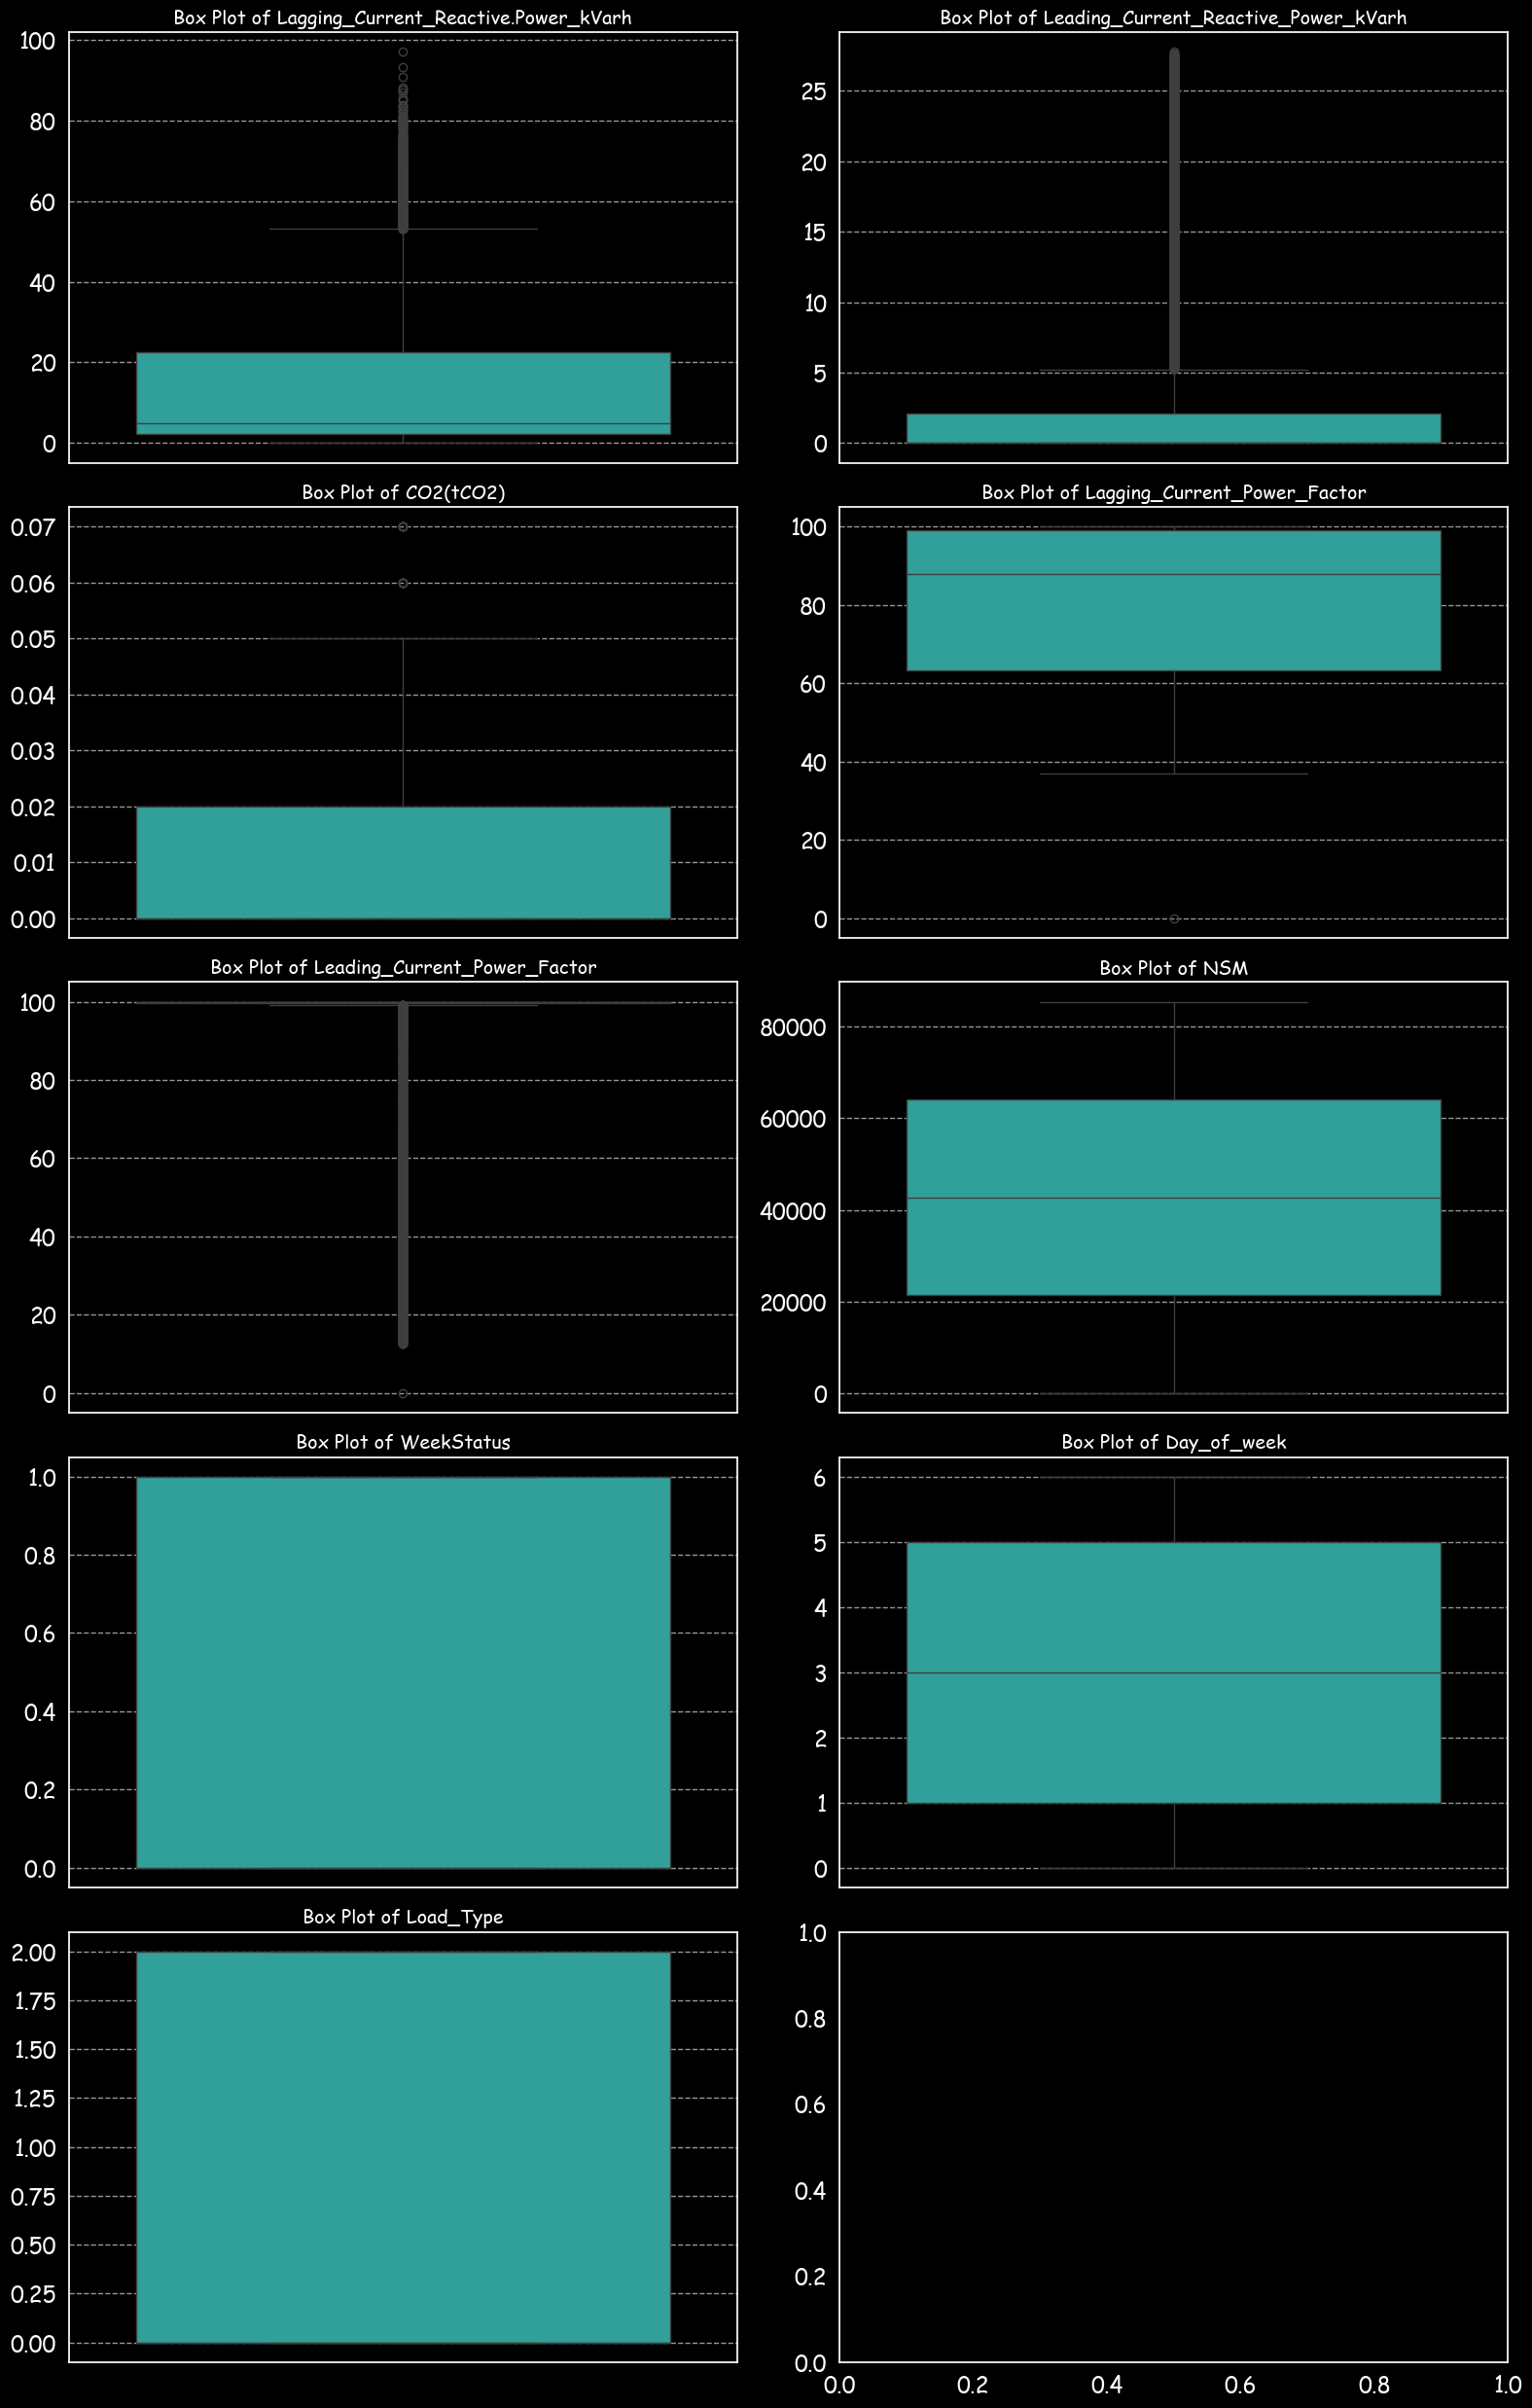

In [36]:

# 시각화할 피처 10개 리스트 (분석 목적에 맞게 조정하세요)
cols = ['Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type']

# 5행 2열 구조로 생성
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 25))
axes = axes.flatten()

for i, col in enumerate(cols):
    if i < len(cols):
        sns.boxplot(y=X[col], ax=axes[i], color='lightseagreen')
        axes[i].set_title(f'Box Plot of {col}', fontsize=14)
        axes[i].set_ylabel('')
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# 레이아웃 정렬 및 출력
plt.tight_layout()
plt.show()

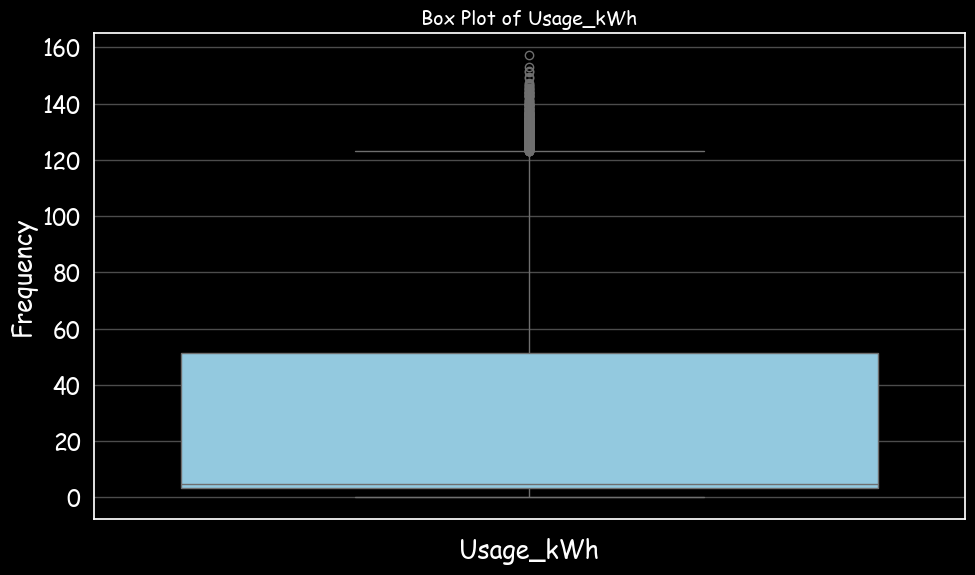

In [38]:
# 시각화할 피처 선택
col = 'Usage_kWh'

# 단일 그래프 생성
plt.figure(figsize=(10, 6))

# y가 Series라면 y, DataFrame이라면 y[col]로 입력하세요.
# 만약 y가 전력 사용량 타겟값(Series)인 경우:
sns.boxplot(y, color='skyblue')

plt.title(f'Box Plot of {col}', fontsize=14)
plt.xlabel(col)
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [40]:
df_incoded.columns

Index(['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')

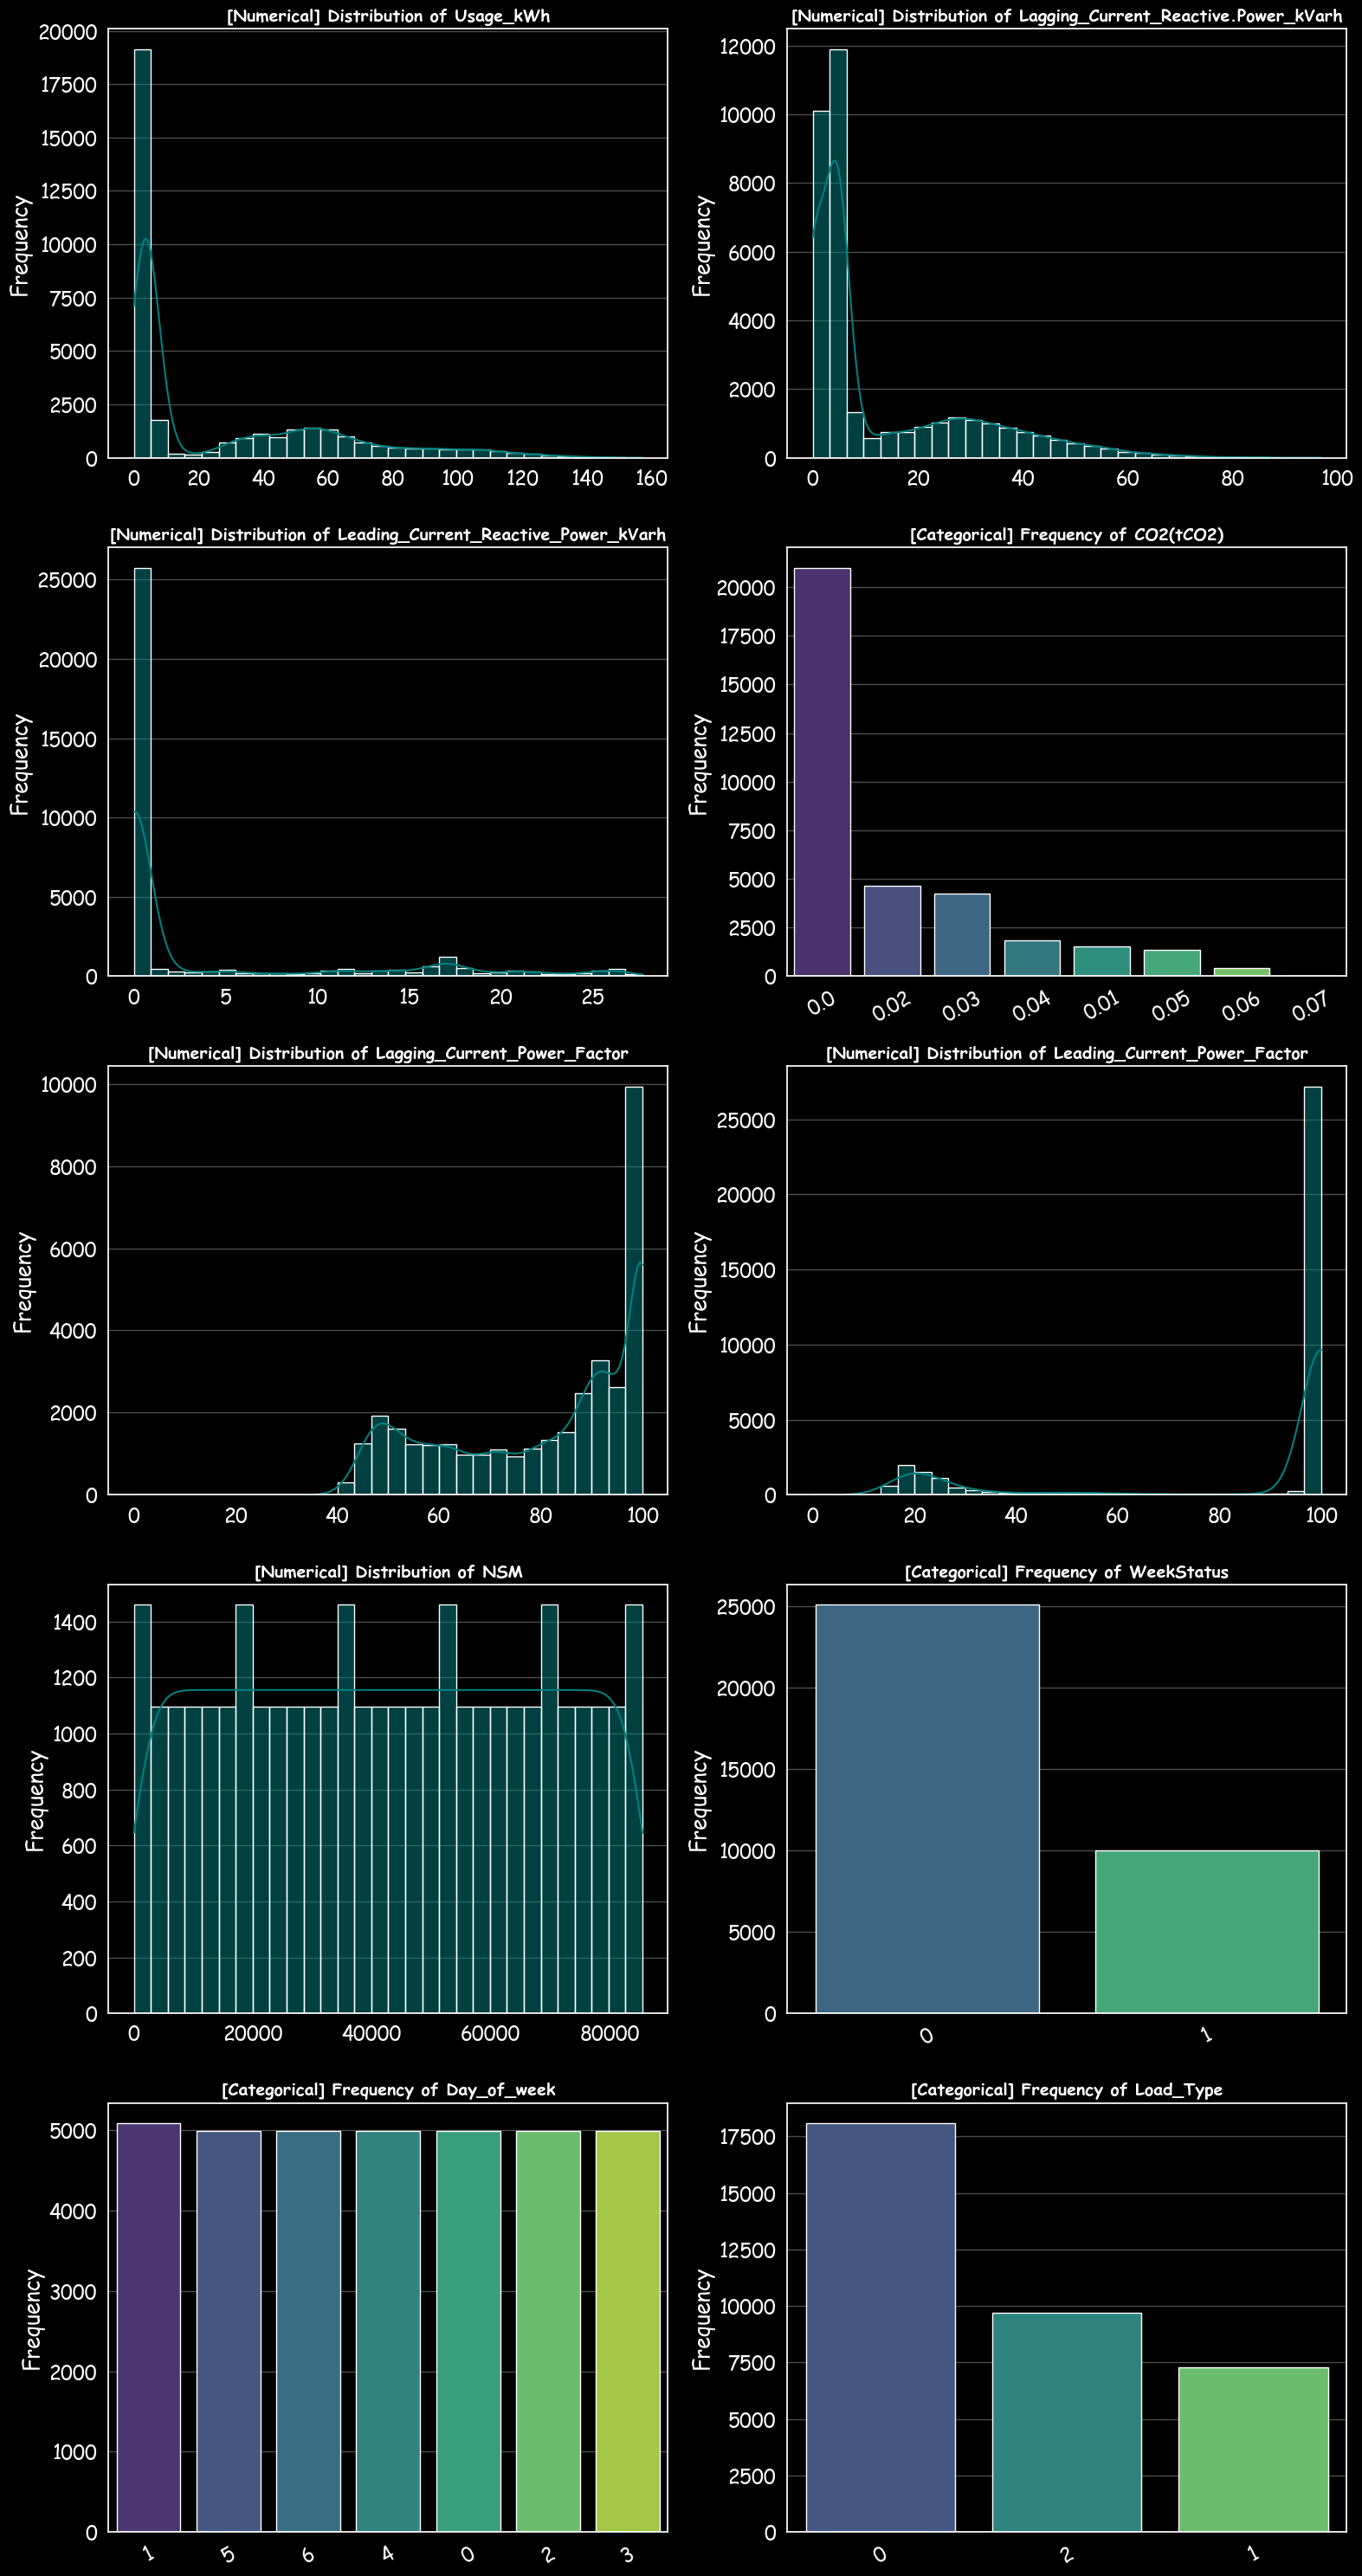

In [41]:
# 1. 분석할 10개 피처 리스트 (데이터 상황에 맞게 조정)
cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type']

# 2. 5행 2열 그리드 설정 (가로로 길게 보는 것보다 세로로 나열하는 것이 가독성이 좋음)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 30))
axes = axes.flatten()

for i, col in enumerate(cols):
    # 데이터 타입 또는 유니크 값 개수에 따라 차트 종류 결정
    # 유니크 값이 적으면 범주형으로 판단하여 countplot 적용
    if df_incoded[col].dtype == 'object' or df_incoded[col].nunique() < 10:
        sns.countplot(data=df_incoded, x=col, ax=axes[i], palette='viridis', order=df_incoded[col].value_counts().index)
        axes[i].set_title(f'[Categorical] Frequency of {col}', fontsize=14, fontweight='bold')
        # 라벨이 겹치지 않게 회전 처리
        axes[i].tick_params(axis='x', rotation=30)
    else:
        # 수치형 데이터는 도수분포의 기본인 histplot 적용
        sns.histplot(df_incoded[col], kde=True, ax=axes[i], color='teal', bins=30)
        axes[i].set_title(f'[Numerical] Distribution of {col}', fontsize=14, fontweight='bold')

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)

# 3. 레이아웃 최적화
plt.tight_layout()
plt.show()

In [42]:
cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type']

print("=== 피처별 도수분포표 (Frequency Table) 분석 ===\n")

for col in cols:
    print(f"[{col}]")
    
    # 범주형이거나 유니크 값이 적은 경우 (원형 그대로 집계)
    if df_incoded[col].dtype == 'object' or df_incoded[col].nunique() < 15:
        counts = df_incoded[col].value_counts().sort_index()
        percent = df_incoded[col].value_counts(normalize=True).sort_index() * 100
    
    # 수치형인 경우 (10개 구간으로 나누어 집계)
    else:
        # 10개 구간으로 분할하여 도수 계산
        binned = pd.cut(df_incoded[col], bins=10)
        counts = binned.value_counts().sort_index()
        percent = binned.value_counts(normalize=True).sort_index() * 100
    
    # 결과 출력 (빈도와 비율을 함께 표시)
    summary = pd.DataFrame({'Count': counts, 'Percentage(%)': percent})
    print(summary)
    print("-" * 50)

=== 피처별 도수분포표 (Frequency Table) 분석 ===

[Usage_kWh]
                    Count  Percentage(%)
Usage_kWh                               
(-0.157, 15.718]    21119      60.271119
(15.718, 31.436]     1116       3.184932
(31.436, 47.154]     3021       8.621575
(47.154, 62.872]     4055      11.572489
(62.872, 78.59]      2275       6.492580
(78.59, 94.308]      1336       3.812785
(94.308, 110.026]    1174       3.350457
(110.026, 125.744]    689       1.966324
(125.744, 141.462]    224       0.639269
(141.462, 157.18]      31       0.088470
--------------------------------------------------
[Lagging_Current_Reactive.Power_kVarh]
                                      Count  Percentage(%)
Lagging_Current_Reactive.Power_kVarh                      
(-0.0969, 9.691]                      23325      66.566781
(9.691, 19.382]                        2051       5.853311
(19.382, 29.073]                       3114       8.886986
(29.073, 38.764]                       2988       8.527397
(38.764, 48.

* 왜도 (Skewness): 데이터의 비대칭성0에 가까울수록: 정규분포에 가깝습니다.
    - 양수 (> 2): 오른쪽으로 꼬리가 매우 깁니다. 전력 데이터에서 흔히 나타나며, **로그 변환($\log(1+x)$)**이 필수적입니다.
    - 음수 (< -2): 왼쪽으로 꼬리가 깁니다. (예: Power_Factor가 100 근처에 몰려 있을 때 발생)
* 첨도 (Kurtosis): 데이터의 뾰족함과 이상치 비중3에 가까울수록: 정규분포의 뾰족함입니다. (Pandas는 기본적으로 3을 뺀 Fisher 첨도를 사용하므로 0이 기준입니다.)
    - 높은 양수: 중앙에 데이터가 극단적으로 몰려 있고, 꼬리가 두껍습니다. 즉, 이상치가 아주 많다는 강력한 증거입니다.
    - 음수: 분포가 완만하고 평평합니다.

In [44]:
# 분석 대상 10개 피처
cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type']

# 수치형 피처만 필터링 (왜도/첨도는 수치형에서만 의미가 있음)
num_cols = df_incoded[cols].select_dtypes(include=['number']).columns

# 통계량 계산
stats_df = pd.DataFrame({
    'Skewness': df_incoded[num_cols].skew(),
    'Kurtosis': df_incoded[num_cols].kurt()
}).sort_values(by='Skewness', ascending=False)

# 해석을 돕기 위한 하이라이트 함수 (절대값 2 이상인 경우 강조)
def highlight_extreme(s):
    is_extreme = s.abs() > 2
    return ['background-color: #ffcccc' if v else '' for v in is_extreme]

print("=== 피처별 왜도(Skew) 및 첨도(Kurtosis) 리포트 ===")
display(stats_df.style.apply(highlight_extreme))

=== 피처별 왜도(Skew) 및 첨도(Kurtosis) 리포트 ===


,Skewness,Kurtosis
Leading_Current_Reactive_Power_kVarh,1.734314,1.581097
Lagging_Current_Reactive.Power_kVarh,1.437899,1.213836
Usage_kWh,1.197394,0.391386
CO2(tCO2),1.149355,0.214605
WeekStatus,0.952975,-1.091902
Load_Type,0.478867,-1.472768
Day_of_week,0.005480,-1.252021
NSM,0.000000,-1.200260
Lagging_Current_Power_Factor,-0.606126,-1.095824
Leading_Current_Power_Factor,-1.511984,0.383301


In [45]:
df_incoded.columns

Index(['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')

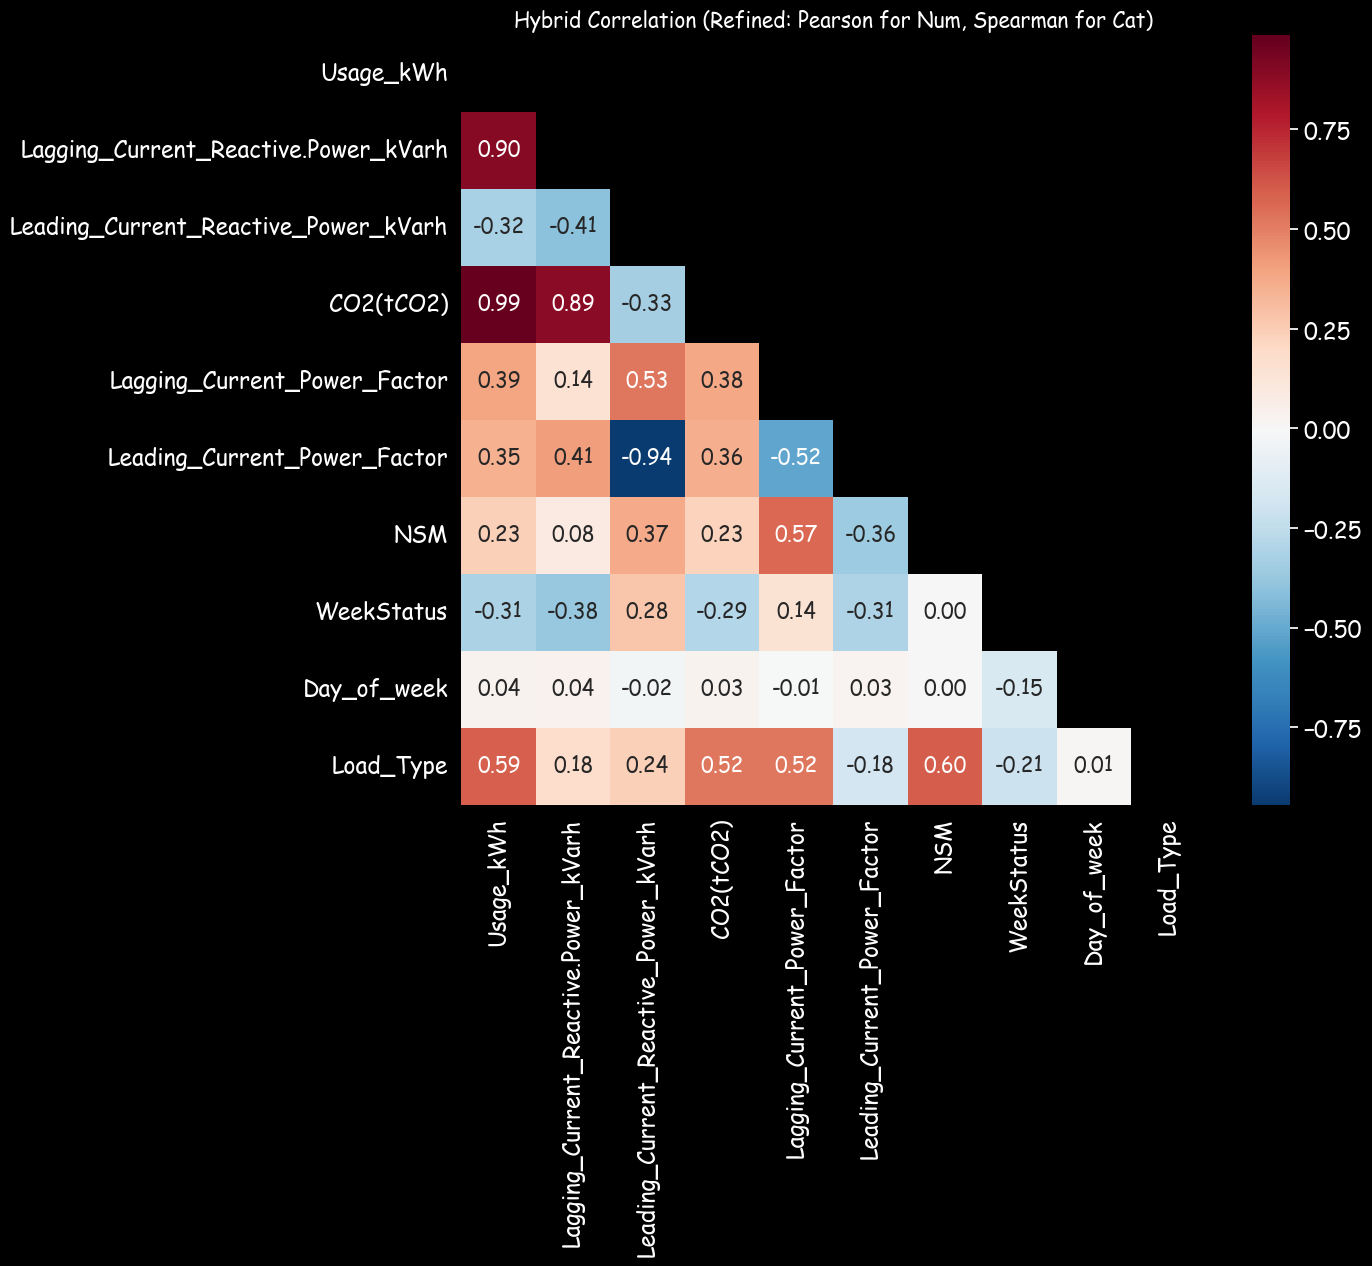

In [46]:


# 1. 사용자가 직접 컬럼 성격 분류 (가장 확실한 방법)
cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']  # 라벨 인코딩된 범주형
num_cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM'
       ]

all_cols = num_cols + cat_cols

def hybrid_correlation_v2(df, all_cols, cat_cols):
    corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)
    
    for col1 in all_cols:
        for col2 in all_cols:
            # 둘 중 하나라도 범주형(라벨인코딩된 것)이 포함되면 Spearman
            if col1 in cat_cols or col2 in cat_cols:
                method = 'spearman'
            # 둘 다 연속형 수치 데이터면 Pearson
            else:
                method = 'pearson'
            
            corr_val = df[col1].corr(df[col2], method=method)
            corr_matrix.loc[col1, col2] = corr_val
            
    return corr_matrix

# 2. 통합 상관계수 계산
integrated_corr = hybrid_correlation_v2(df_incoded, all_cols, cat_cols)

# 3. 시각화
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(integrated_corr, dtype=bool))

sns.heatmap(integrated_corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Hybrid Correlation (Refined: Pearson for Num, Spearman for Cat)', fontsize=15)
plt.show()